# Week 7 Lab: Cross-Sectional Stock Ranking

**BUS 696: Generative AI in Finance**
**Professor Jonathan Hersh — Spring 2026**

---

## The Question

> Can ML rank which stocks will outperform next month — and can we build a portfolio from those rankings?

In Week 5 we learned that predicting daily SPY direction is brutally hard (~50% accuracy). Today we try something **closer to real quant practice**: instead of predicting one index, we **rank stocks** against each other.

## Why This Is Better

| SPY Direction (Week 5) | Cross-Sectional Ranking (Today) |
|---|---|
| 1 label per day | 30 labels per month |
| Absolute prediction (up or down?) | Relative prediction (which stocks beat others?) |
| Highly arbitraged single index | More variation across individual stocks |
| Hard to turn into a real strategy | Natural portfolio construction |

## What You'll Do (~1 hour)

| Part | Topic | Time | What You Do |
|------|-------|------|-------------|
| 1 | Setup & Data | 5 min | Download prices, build features |
| 2 | Cross-Sectional Intuition | 5 min | See why ranking works |
| 3 | Model Horse Race | 10 min | Compare 4 models on ranking ability |
| 4 | Walk-Forward Portfolio | 15 min | Build and test a real portfolio |
| 5 | Honest Evaluation | 10 min | Transaction costs and turnover |
| 6 | What Drives the Signal? | 5 min | Feature importance |
| 7 | Your Conclusion | 10 min | Written analysis |

## Core Deliverables
1. Model comparison: which model ranks stocks best?
2. Walk-forward portfolio returns with transaction costs
3. **Written conclusion**: Is cross-sectional ranking a viable strategy? (3–5 sentences)

---

## Part 1: Setup & Data (~5 min)

Run these two cells to load libraries and download monthly data for 30 large-cap US stocks across sectors.

In [1]:
# ============================================================
# SETUP: Libraries and color palette
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

NAVY = '#1E2761'
CORAL = '#F96167'
TEAL = '#028090'
GOLD = '#F9A825'
GRAY = '#6c757d'
GREEN = '#2E7D32'

np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


In [2]:
# ============================================================
# DATA: Download 30 large-cap stocks + SPY, build features
# ============================================================
tickers = [
    # Tech
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'GOOGL',
    # Finance
    'JPM', 'BAC', 'GS', 'BLK',
    # Healthcare
    'UNH', 'JNJ', 'PFE', 'LLY', 'ABBV',
    # Consumer
    'PG', 'KO', 'WMT', 'COST', 'MCD', 'HD',
    # Energy
    'XOM', 'CVX',
    # Industrial
    'CAT', 'HON', 'BA', 'GE',
    # Other
    'CRM', 'ADBE', 'NEE',
]

print(f'Downloading monthly data for {len(tickers)} stocks + SPY...')
raw = yf.download(tickers + ['SPY'], start='2010-01-01', end='2024-12-31')
prices = raw['Close']
monthly = prices.resample('ME').last()

# Compute features from monthly prices
rets_1m = monthly.pct_change(1)
rets_3m = monthly.pct_change(3)
rets_6m = monthly.pct_change(6)
rets_12m = monthly.pct_change(12)
vol_3m = rets_1m.rolling(3).std()
vol_6m = rets_1m.rolling(6).std()

# Target: next-month return (shifted forward)
target = rets_1m.shift(-1)

# SPY returns for benchmarking
spy_next = rets_1m['SPY'].shift(-1)

# Build panel dataset (one row per stock per month)
panel = []
for t in monthly.index[12:-1]:  # Need 12 months of history
    for ticker in tickers:
        try:
            row = {
                'date': t,
                'ticker': ticker,
                'ret_1m': rets_1m.loc[t, ticker],
                'ret_3m': rets_3m.loc[t, ticker],
                'ret_6m': rets_6m.loc[t, ticker],
                'ret_12m': rets_12m.loc[t, ticker],
                'vol_3m': vol_3m.loc[t, ticker],
                'vol_6m': vol_6m.loc[t, ticker],
                'target': target.loc[t, ticker],
                'spy_next': spy_next.loc[t],
            }
            panel.append(row)
        except KeyError:
            continue

data = pd.DataFrame(panel).dropna()

features = ['ret_1m', 'ret_3m', 'ret_6m', 'ret_12m', 'vol_3m', 'vol_6m']
dates = sorted(data['date'].unique())

print(f'\nPanel dataset: {len(data):,} stock-month observations')
print(f'Date range: {dates[0].strftime("%Y-%m")} to {dates[-1].strftime("%Y-%m")}')
print(f'Stocks: {len(tickers)} | Months: {len(dates)} | Features: {len(features)}')
print(f'\nFeatures: {features}')
print(f'Target: next-month return')

[*********************100%***********************]  31 of 31 completed



Panel dataset: 4,946 stock-month observations
Date range: 2011-01 to 2024-11
Stocks: 30 | Months: 167 | Features: 6

Features: ['ret_1m', 'ret_3m', 'ret_6m', 'ret_12m', 'vol_3m', 'vol_6m']
Target: next-month return


---

## Part 2: Why Cross-Sectional Prediction Works Better (~5 min)

The key insight: **each month gives us 30 data points** (one per stock), not just one. And we're asking a simpler question — not "will the market go up?" but "which stocks will do relatively better?"

Run this cell to see the cross-sectional dispersion in monthly returns.

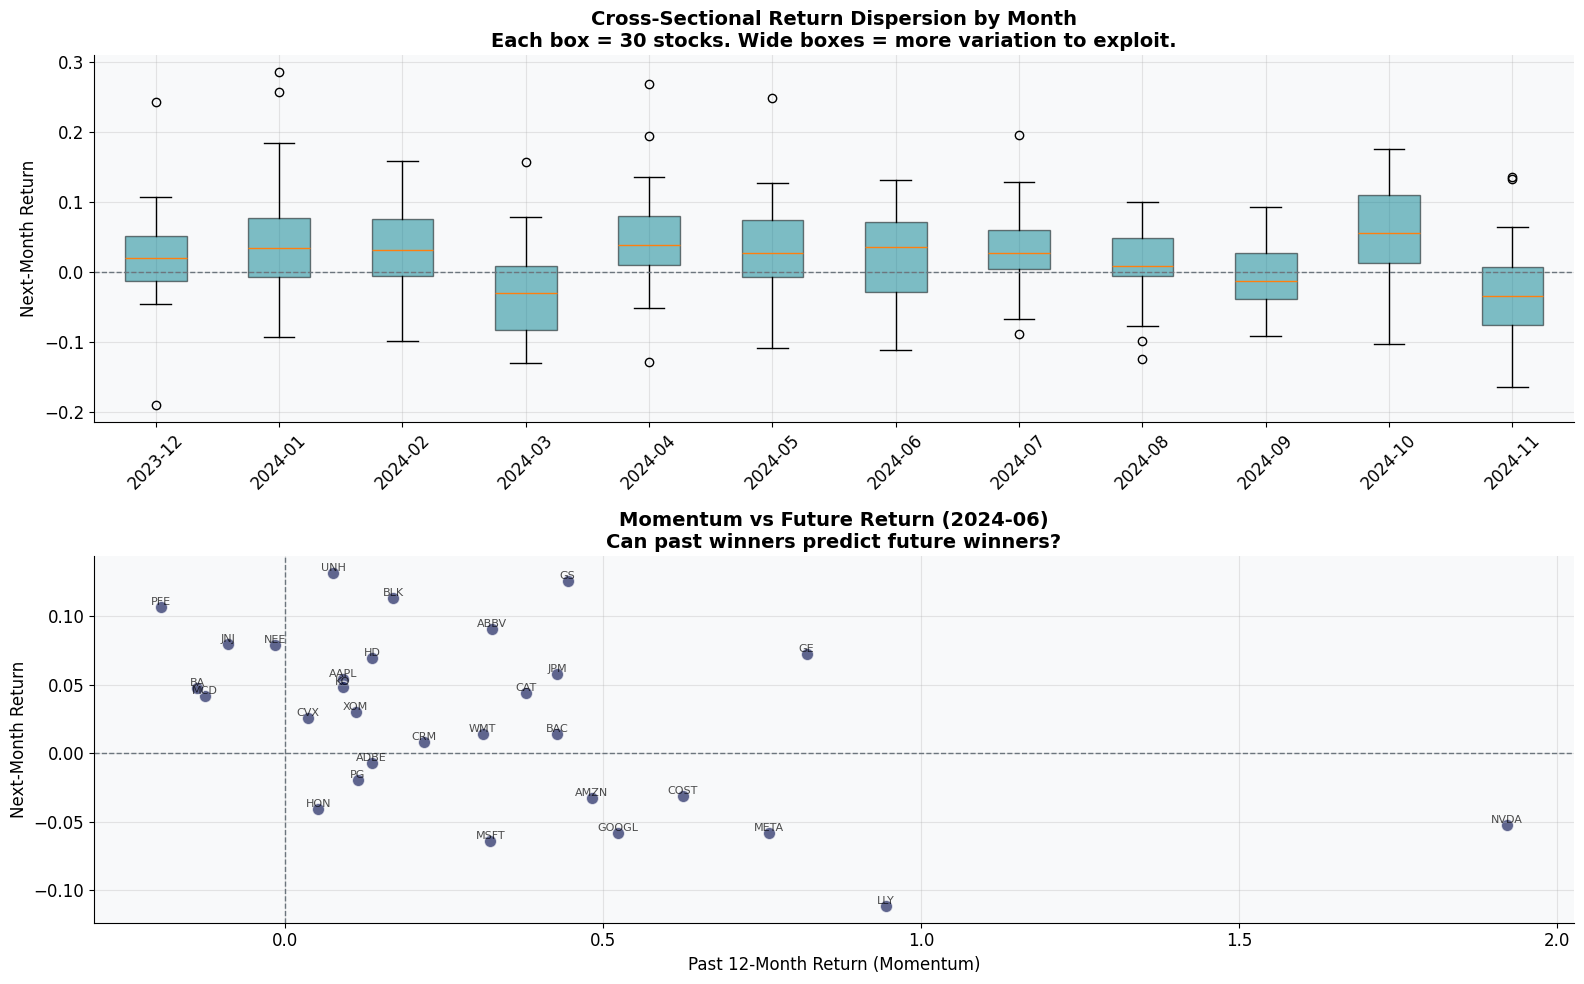

Average monthly spread (best - worst stock): 26.5%
If we can predict even part of this spread, we have a strategy.


In [3]:
# ============================================================
# How much do stocks differ each month?
# ============================================================
sample_dates = dates[-12:]  # Last 12 months

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top: Box plot of monthly returns by month
monthly_returns = []
labels = []
for d in sample_dates:
    month_data = data[data['date'] == d]['target'].values
    monthly_returns.append(month_data)
    labels.append(d.strftime('%Y-%m'))

bp = axes[0].boxplot(monthly_returns, labels=labels, patch_artist=True)
for box in bp['boxes']:
    box.set_facecolor(TEAL)
    box.set_alpha(0.5)
axes[0].axhline(y=0, color=GRAY, linewidth=1, linestyle='--')
axes[0].set_ylabel('Next-Month Return')
axes[0].set_title('Cross-Sectional Return Dispersion by Month\n'
                   'Each box = 30 stocks. Wide boxes = more variation to exploit.',
                   fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Bottom: Scatter of momentum vs next month's return
recent_date = dates[-6]
recent = data[data['date'] == recent_date]
ax = axes[1]
ax.scatter(recent['ret_12m'], recent['target'], c=NAVY, s=80, alpha=0.7,
           edgecolors='white', linewidth=1)
for _, row in recent.iterrows():
    ax.annotate(row['ticker'], (row['ret_12m'], row['target']),
                fontsize=8, ha='center', va='bottom', alpha=0.7)
ax.axhline(y=0, color=GRAY, linewidth=1, linestyle='--')
ax.axvline(x=0, color=GRAY, linewidth=1, linestyle='--')
ax.set_xlabel('Past 12-Month Return (Momentum)')
ax.set_ylabel('Next-Month Return')
ax.set_title(f'Momentum vs Future Return ({recent_date.strftime("%Y-%m")})\n'
             'Can past winners predict future winners?', fontweight='bold')

plt.tight_layout()
plt.show()

spread = data.groupby('date')['target'].apply(lambda x: x.max() - x.min())
print(f'Average monthly spread (best - worst stock): {spread.mean():.1%}')
print(f'If we can predict even part of this spread, we have a strategy.')

### Checkpoint 1: Cross-Sectional Intuition

1. **Look at the box plots.** In which months is the spread between best and worst stocks largest? What market conditions might cause wider or narrower spreads?

2. **Look at the scatter plot.** Is there a visible relationship between past momentum and future returns? Would you call it strong or weak?

3. **Why is ranking 30 stocks easier than predicting SPY direction?** Think about the difference between "will the market go up?" vs "which stocks will do relatively better?"

*Write your answers:*

### Checkpoint 1 Responses

1. Widest spreads appear in months like 2024-01, 2024-04, and 2024-10 (taller boxes/whiskers), while 2024-03 and 2024-11 are tighter. Wider spreads are more common in choppier or rotation-heavy markets, where sector dispersion is higher.

2. Momentum vs future return looks weak-to-moderate, not strong. There is some positive pattern, but notable outliers (for example, very high momentum names with weak next-month returns) show noise.

3. Ranking 30 stocks is easier than predicting SPY direction because each month gives cross-sectional signal instead of one market-level label. We are asking a relative question (who beats whom), which is closer to portfolio construction and less fragile than binary index timing.

---

## Part 3: Model Horse Race — Who Ranks Best? (~10 min)

We compare 4 models, but the metric is different from Week 5. Instead of accuracy, we measure the **Information Coefficient (IC)** — the Spearman rank correlation between predicted returns and actual returns.

- **IC = 0**: model rankings are random (no skill)
- **IC > 0.05**: meaningful ranking ability
- **IC > 0.10**: very good for real-world finance

This is how quant hedge funds evaluate their alpha models.

In [5]:
# ============================================================
# MODEL HORSE RACE: Which model ranks stocks best?
# ============================================================
np.random.seed(42)

# Use last 36 months as test, everything before as train
split_idx = len(dates) - 36
train_dates_hr = dates[:split_idx]
test_dates_hr = dates[split_idx:]

train_hr = data[data['date'].isin(train_dates_hr)]
test_hr = data[data['date'].isin(test_dates_hr)]

X_train_hr = train_hr[features].values
y_train_hr = train_hr['target'].values
X_test_hr = test_hr[features].values
y_test_hr = test_hr['target'].values

# Normalize
scaler_hr = StandardScaler()
X_train_hr_s = scaler_hr.fit_transform(X_train_hr)
X_test_hr_s = scaler_hr.transform(X_test_hr)

models_hr = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=4, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, max_depth=3, random_state=42),
    'Dense NN (2x64)': MLPRegressor(
        hidden_layer_sizes=(64, 64), max_iter=500, random_state=42,
        early_stopping=True, learning_rate='adaptive', batch_size=64),
}

print('Model Horse Race: Who Ranks Stocks Best?')
print('=' * 65)
print(f'  {"Model":25s}  {"Test IC":>10s}  {"Train IC":>10s}')
print('-' * 65)

hr_results = {}
for name, model in models_hr.items():
    model.fit(X_train_hr_s, y_train_hr)

    # Train IC (per-month Spearman correlation, then average)
    train_pred = model.predict(X_train_hr_s)
    train_ic_list = []
    for d in train_dates_hr:
        mask = (train_hr['date'] == d).values
        if mask.sum() > 5:
            ic, _ = spearmanr(train_pred[mask], y_train_hr[mask])
            if not np.isnan(ic):
                train_ic_list.append(ic)

    # Test IC (per-month)
    test_pred = model.predict(X_test_hr_s)
    test_ic_list = []
    for d in test_dates_hr:
        mask = (test_hr['date'] == d).values
        if mask.sum() > 5:
            ic, _ = spearmanr(test_pred[mask], y_test_hr[mask])
            if not np.isnan(ic):
                test_ic_list.append(ic)

    train_ic = np.mean(train_ic_list)
    test_ic = np.mean(test_ic_list)
    hr_results[name] = {'train_ic': train_ic, 'test_ic': test_ic,
                         'test_ics': test_ic_list}
    print(f'  {name:25s}  {test_ic:>10.3f}  {train_ic:>10.3f}')

print(f'\nIC > 0.05 = meaningful signal.  IC > 0.10 = very strong.')
print(f'Compare to Week 5: we now have a number that tells us about RANKING quality.')

Model Horse Race: Who Ranks Stocks Best?
  Model                         Test IC    Train IC
-----------------------------------------------------------------
  Linear Regression               0.070       0.007
  Random Forest                   0.076       0.111
  Gradient Boosting               0.027       0.403
  Dense NN (2x64)                 0.026       0.196

IC > 0.05 = meaningful signal.  IC > 0.10 = very strong.
Compare to Week 5: we now have a number that tells us about RANKING quality.


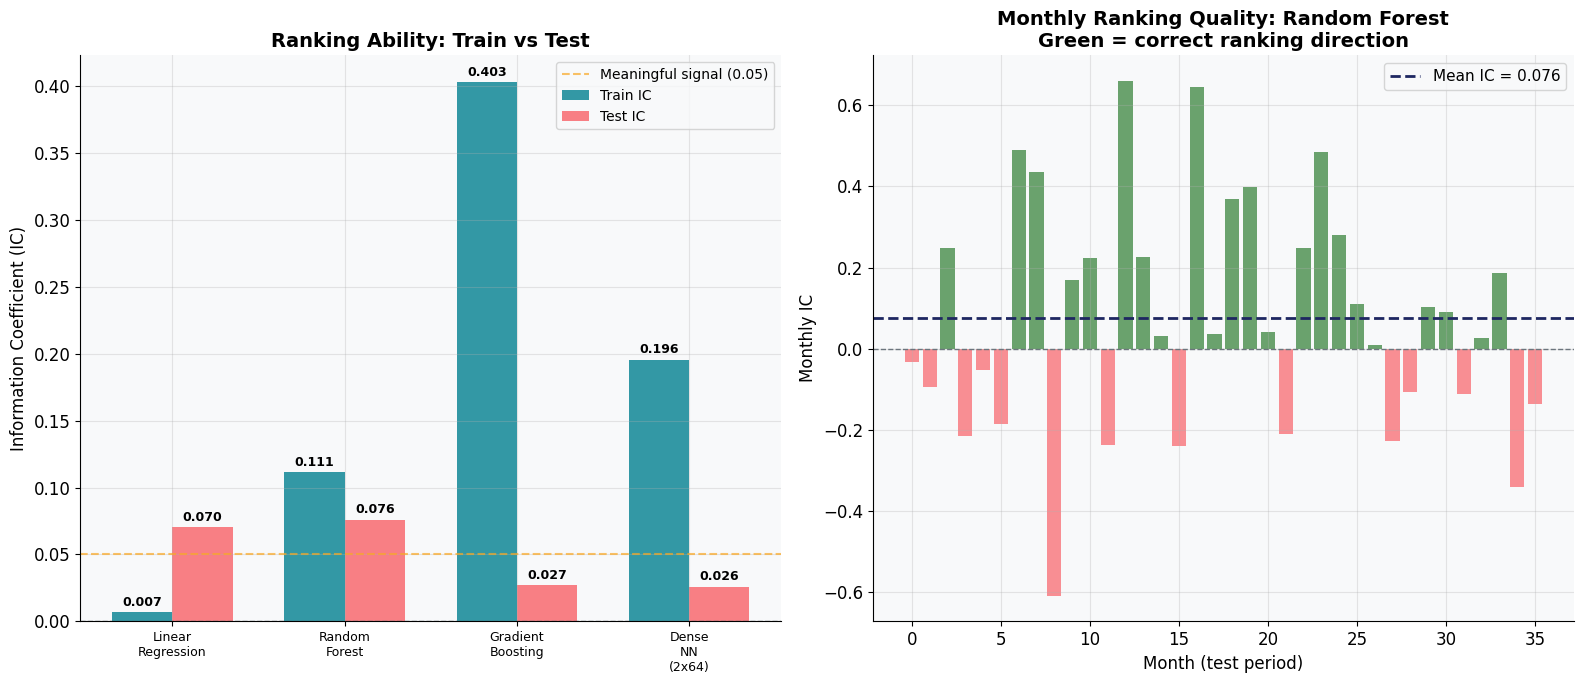

Best model: Random Forest (IC = 0.076)
Positive IC months: 61% — the model ranks correctly more often than not.


In [6]:
# ============================================================
# VISUALIZE: IC comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

names_hr = list(hr_results.keys())
test_ics = [hr_results[n]['test_ic'] for n in names_hr]
train_ics = [hr_results[n]['train_ic'] for n in names_hr]

x_pos = np.arange(len(names_hr))
width = 0.35

# Left: IC comparison
ax = axes[0]
ax.bar(x_pos - width/2, train_ics, width, label='Train IC', color=TEAL, alpha=0.8)
ax.bar(x_pos + width/2, test_ics, width, label='Test IC', color=CORAL, alpha=0.8)
ax.axhline(y=0, color=GRAY, linewidth=1, linestyle='--')
ax.axhline(y=0.05, color=GOLD, linewidth=1.5, linestyle='--', alpha=0.7,
           label='Meaningful signal (0.05)')
ax.set_ylabel('Information Coefficient (IC)')
ax.set_title('Ranking Ability: Train vs Test', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([n.replace(' ', '\n') for n in names_hr], fontsize=9)
ax.legend(fontsize=10)
for i in range(len(names_hr)):
    ax.text(i - width/2, train_ics[i] + 0.005, f'{train_ics[i]:.3f}',
            ha='center', fontsize=9, fontweight='bold')
    ax.text(i + width/2, test_ics[i] + 0.005, f'{test_ics[i]:.3f}',
            ha='center', fontsize=9, fontweight='bold')

# Right: Monthly IC time series for best model
best_model = max(hr_results, key=lambda k: hr_results[k]['test_ic'])
ax = axes[1]
monthly_ics = hr_results[best_model]['test_ics']
colors_ic = [GREEN if ic > 0 else CORAL for ic in monthly_ics]
ax.bar(range(len(monthly_ics)), monthly_ics, color=colors_ic, alpha=0.7)
ax.axhline(y=0, color=GRAY, linewidth=1, linestyle='--')
ax.axhline(y=np.mean(monthly_ics), color=NAVY, linewidth=2, linestyle='--',
           label=f'Mean IC = {np.mean(monthly_ics):.3f}')
ax.set_xlabel('Month (test period)')
ax.set_ylabel('Monthly IC')
ax.set_title(f'Monthly Ranking Quality: {best_model}\n'
             f'Green = correct ranking direction', fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f'Best model: {best_model} (IC = {hr_results[best_model]["test_ic"]:.3f})')
frac_pos = sum(1 for ic in monthly_ics if ic > 0) / len(monthly_ics)
print(f'Positive IC months: {frac_pos:.0%} — the model ranks correctly more often than not.')

---

## Part 4: Walk-Forward Portfolio Construction (~15 min)

Now we do it honestly: **expanding-window walk-forward** with monthly rebalancing.

Each month:
1. Train on all prior months
2. Predict next-month returns for all 30 stocks
3. Rank stocks by predicted return
4. Go **long** the top quintile (best 6 stocks), **short** the bottom quintile (worst 6)
5. Record the portfolio return

This takes ~1–2 minutes to run.

In [7]:
# ============================================================
# WALK-FORWARD PORTFOLIO BACKTEST
# ============================================================
np.random.seed(42)

def walk_forward_ranking(data, features, model_class, model_kwargs,
                         min_train_months=36):
    dates_all = sorted(data['date'].unique())
    results = []

    for i in range(min_train_months, len(dates_all) - 1):
        train_dates = dates_all[:i]
        test_date = dates_all[i]

        train = data[data['date'].isin(train_dates)]
        test = data[data['date'] == test_date].copy()

        if len(test) < 10:
            continue

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(train[features])
        y_tr = train['target'].values
        X_te = scaler.transform(test[features])

        model = model_class(**model_kwargs)
        model.fit(X_tr, y_tr)
        test['pred'] = model.predict(X_te)

        # Rank and form quintile portfolios
        test = test.sort_values('pred', ascending=False)
        n = len(test)
        q_size = max(1, n // 5)

        top_q = test.head(q_size)
        bot_q = test.tail(q_size)

        top_ret = top_q['target'].mean()
        bot_ret = bot_q['target'].mean()
        ls_ret = top_ret - bot_ret
        mkt_ret = test['target'].mean()

        ic, _ = spearmanr(test['pred'], test['target'])

        results.append({
            'date': test_date,
            'top_quintile': top_ret,
            'bottom_quintile': bot_ret,
            'long_short': ls_ret,
            'equal_weight': mkt_ret,
            'ic': ic if not np.isnan(ic) else 0.0,
            'top_names': list(top_q['ticker'].values),
            'bot_names': list(bot_q['ticker'].values),
        })

    results_df = pd.DataFrame(results).set_index('date')
    return results_df

# Run with Random Forest
print('Running walk-forward backtest (~1-2 minutes)...\n')
wf = walk_forward_ranking(
    data, features,
    RandomForestRegressor,
    {'n_estimators': 200, 'max_depth': 4, 'random_state': 42},
    min_train_months=36,
)

# Print year-by-year summary
print('Walk-Forward Results by Year')
print('=' * 70)
print(f'  {"Year":>6s}  {"Top Q":>8s}  {"Bot Q":>8s}  {"L/S":>8s}  {"IC":>7s}')
print('-' * 70)
for year in sorted(wf.index.year.unique()):
    yr = wf[wf.index.year == year]
    print(f'  {year:>6d}  {yr["top_quintile"].mean():>7.1%}  '
          f'{yr["bottom_quintile"].mean():>7.1%}  '
          f'{yr["long_short"].mean():>7.1%}  '
          f'{yr["ic"].mean():>7.3f}')

overall_ls = wf['long_short'].mean()
overall_ic = wf['ic'].mean()
print(f'\n  Overall: L/S {overall_ls:.2%}/month | IC {overall_ic:.3f} | '
      f'{len(wf)} months')

Running walk-forward backtest (~1-2 minutes)...

Walk-Forward Results by Year
    Year     Top Q     Bot Q       L/S       IC
----------------------------------------------------------------------
    2014     1.0%     1.5%    -0.6%   -0.068
    2015     1.0%     1.0%     0.0%   -0.075
    2016     4.0%     1.5%     2.5%    0.141
    2017     3.6%     3.3%     0.3%   -0.052
    2018    -0.8%     0.4%    -1.2%   -0.037
    2019     2.8%     2.4%     0.4%    0.081
    2020     0.3%     3.1%    -2.8%   -0.139
    2021     2.9%     1.1%     1.8%    0.064
    2022     1.5%     1.0%     0.5%    0.023
    2023     4.8%     0.5%     4.3%    0.215
    2024     2.6%     2.2%     0.4%   -0.040

  Overall: L/S 0.52%/month | IC 0.011 | 130 months


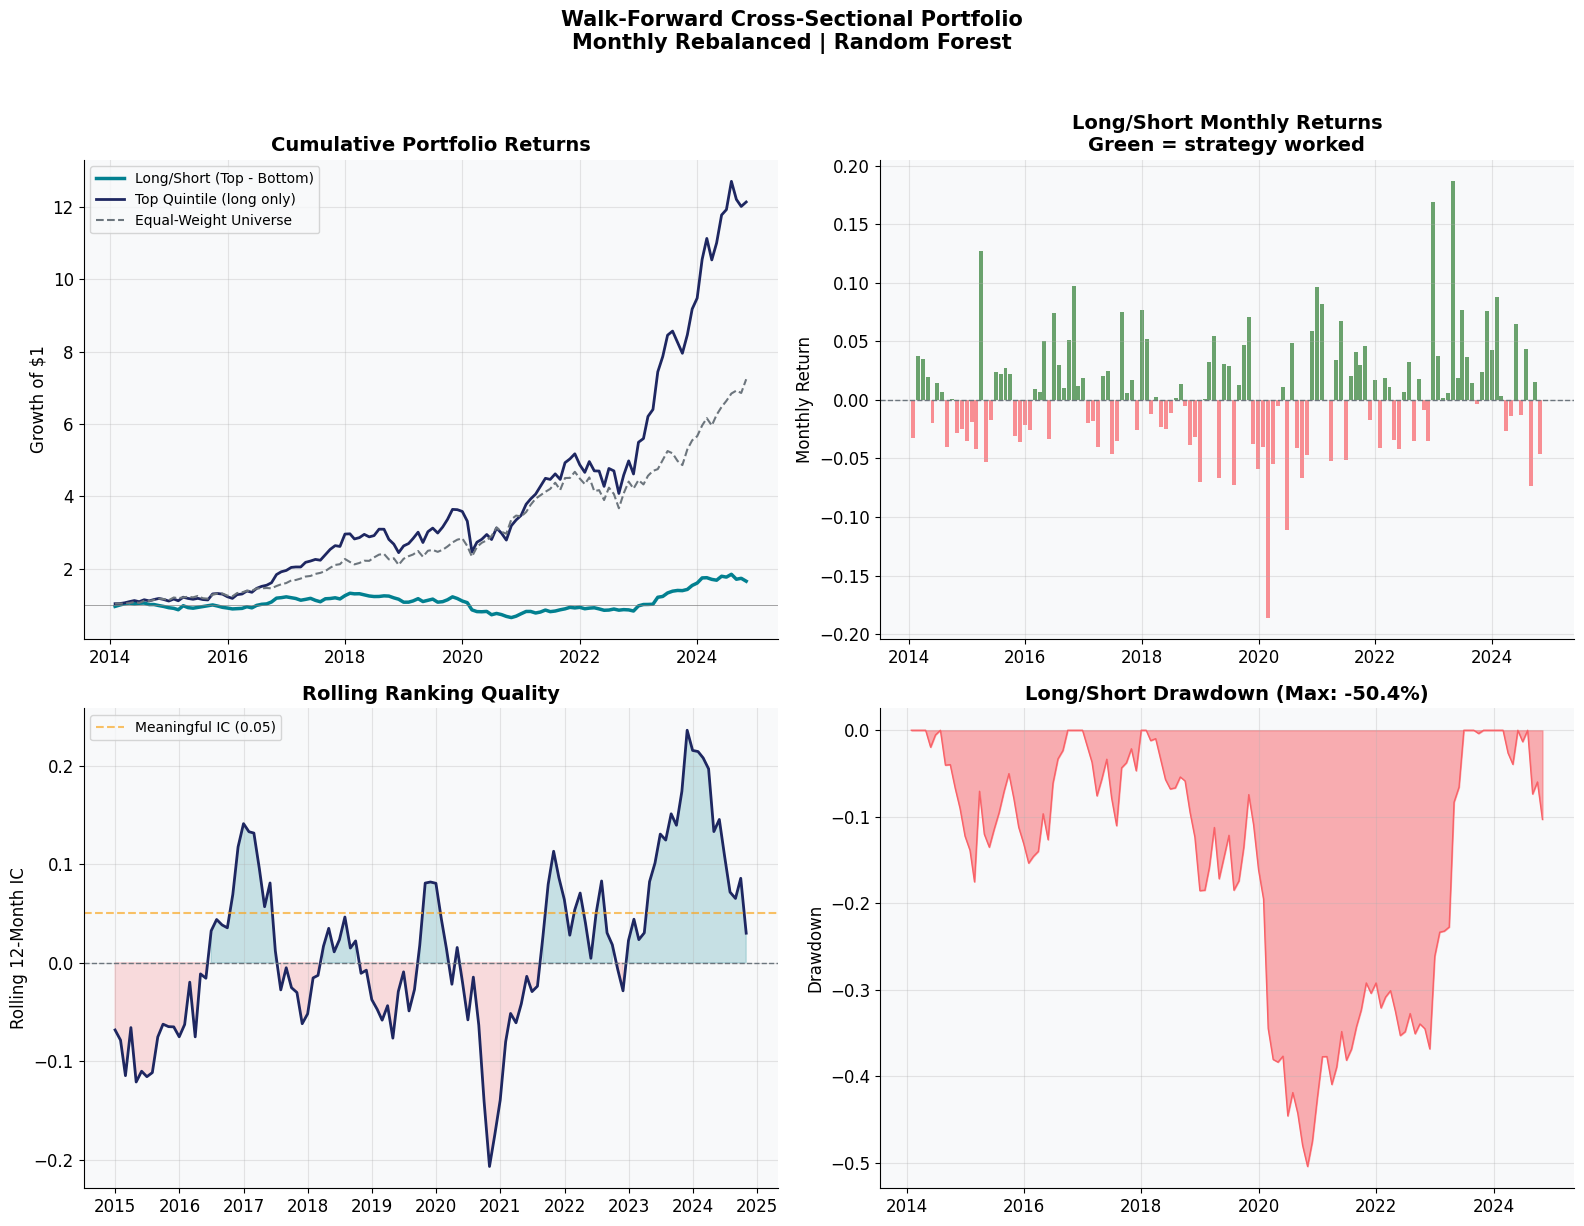


Annualized Performance Summary:
------------------------------------------------------------
  Strategy                     Return       Vol   Sharpe
------------------------------------------------------------
  Long/Short                    6.2%    17.4%     0.36
  Top Quintile (long)          25.7%
  Equal-Weight Universe        19.5%

  Hit rate (months L/S > 0): 57%
  Max drawdown: -50.4%


In [8]:
# ============================================================
# DASHBOARD: Walk-forward portfolio performance
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Cumulative returns
wf['cum_ls'] = (1 + wf['long_short']).cumprod()
wf['cum_top'] = (1 + wf['top_quintile']).cumprod()
wf['cum_ew'] = (1 + wf['equal_weight']).cumprod()

ax = axes[0, 0]
ax.plot(wf.index, wf['cum_ls'], color=TEAL, linewidth=2.5,
        label='Long/Short (Top - Bottom)')
ax.plot(wf.index, wf['cum_top'], color=NAVY, linewidth=2,
        label='Top Quintile (long only)')
ax.plot(wf.index, wf['cum_ew'], color=GRAY, linewidth=1.5,
        linestyle='--', label='Equal-Weight Universe')
ax.axhline(y=1, color='gray', linewidth=0.5)
ax.set_ylabel('Growth of $1')
ax.set_title('Cumulative Portfolio Returns', fontweight='bold')
ax.legend(fontsize=10)

# Monthly L/S returns
ax = axes[0, 1]
colors_ls = [GREEN if r > 0 else CORAL for r in wf['long_short']]
ax.bar(wf.index, wf['long_short'], color=colors_ls, alpha=0.7, width=25)
ax.axhline(y=0, color=GRAY, linewidth=1, linestyle='--')
ax.set_ylabel('Monthly Return')
ax.set_title('Long/Short Monthly Returns\nGreen = strategy worked', fontweight='bold')

# Rolling IC
ax = axes[1, 0]
rolling_ic = wf['ic'].rolling(12).mean()
ax.plot(wf.index, rolling_ic, color=NAVY, linewidth=2)
ax.fill_between(wf.index, 0, rolling_ic,
                where=rolling_ic > 0, alpha=0.2, color=TEAL)
ax.fill_between(wf.index, 0, rolling_ic,
                where=rolling_ic < 0, alpha=0.2, color=CORAL)
ax.axhline(y=0, color=GRAY, linewidth=1, linestyle='--')
ax.axhline(y=0.05, color=GOLD, linewidth=1.5, linestyle='--', alpha=0.7,
           label='Meaningful IC (0.05)')
ax.set_ylabel('Rolling 12-Month IC')
ax.set_title('Rolling Ranking Quality', fontweight='bold')
ax.legend(fontsize=10)

# Drawdown
ax = axes[1, 1]
running_max = wf['cum_ls'].cummax()
drawdown = (wf['cum_ls'] - running_max) / running_max
ax.fill_between(wf.index, drawdown, 0, color=CORAL, alpha=0.5)
ax.plot(wf.index, drawdown, color=CORAL, linewidth=1)
ax.set_ylabel('Drawdown')
ax.set_title(f'Long/Short Drawdown (Max: {drawdown.min():.1%})', fontweight='bold')

plt.suptitle('Walk-Forward Cross-Sectional Portfolio\n'
             'Monthly Rebalanced | Random Forest',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
ls_ann = wf['long_short'].mean() * 12
ls_vol = wf['long_short'].std() * np.sqrt(12)
ls_sharpe = ls_ann / ls_vol if ls_vol > 0 else 0
top_ann = wf['top_quintile'].mean() * 12
ew_ann = wf['equal_weight'].mean() * 12
hit_rate = (wf['long_short'] > 0).mean()

print('\nAnnualized Performance Summary:')
print('-' * 60)
print(f'  {"Strategy":25s}  {"Return":>8s}  {"Vol":>8s}  {"Sharpe":>7s}')
print('-' * 60)
print(f'  {"Long/Short":25s}  {ls_ann:>7.1%}  {ls_vol:>7.1%}  {ls_sharpe:>7.2f}')
print(f'  {"Top Quintile (long)":25s}  {top_ann:>7.1%}')
print(f'  {"Equal-Weight Universe":25s}  {ew_ann:>7.1%}')
print(f'\n  Hit rate (months L/S > 0): {hit_rate:.0%}')
print(f'  Max drawdown: {drawdown.min():.1%}')

### Checkpoint 2: Evaluating the Strategy

1. **Compare the long/short strategy to the equal-weight universe.** Does picking stocks add value over just holding everything equally?

2. **Look at the monthly return bars.** What fraction of months does the long/short strategy make money? Is it consistent, or are there long losing streaks?

3. **Look at the rolling IC.** Are there periods where the model's ranking ability breaks down? What might cause that? (Hint: think about 2020, 2022.)

4. **Compare this to Week 5's SPY result.** Which feels more like a real investment process? Why?

*Write your answers:*

### Checkpoint 2 Responses

1. Stock selection value is mixed in this run. Long/short earns about 6.2% annualized (monthly mean about 0.52%), but the equal-weight universe is stronger at about 19.5% annualized. Top-quintile long-only is strongest at about 25.7% annualized, so the short leg drags the combined long/short result.

2. The long/short hit rate is 56.9%, so it wins more often than not, but returns are uneven. There are clear losing stretches, and max drawdown is about -50.4%, so consistency is limited.

3. Rolling IC does break down in some periods (notably around 2020-2021), then recovers in 2023-2024. That is consistent with regime shifts where relationships between momentum/volatility features and next-month returns change.

4. Compared with Week 5 SPY direction, this is much closer to a real investment workflow. We use cross-sectional ranking, walk-forward training, portfolio rules, and cost-aware evaluation instead of only directional accuracy.

---

## Part 5: Honest Evaluation — Transaction Costs & Turnover (~10 min)

Monthly rebalancing means we buy and sell stocks each month. Each trade costs money. Let's measure:
- **Turnover**: how many stocks enter/exit the portfolio each month
- **Net returns**: after applying realistic trading costs (20 bps round-trip for large-cap stocks)

Compare this to Week 5, where daily SPY trading at 5 bps destroyed most of the alpha.

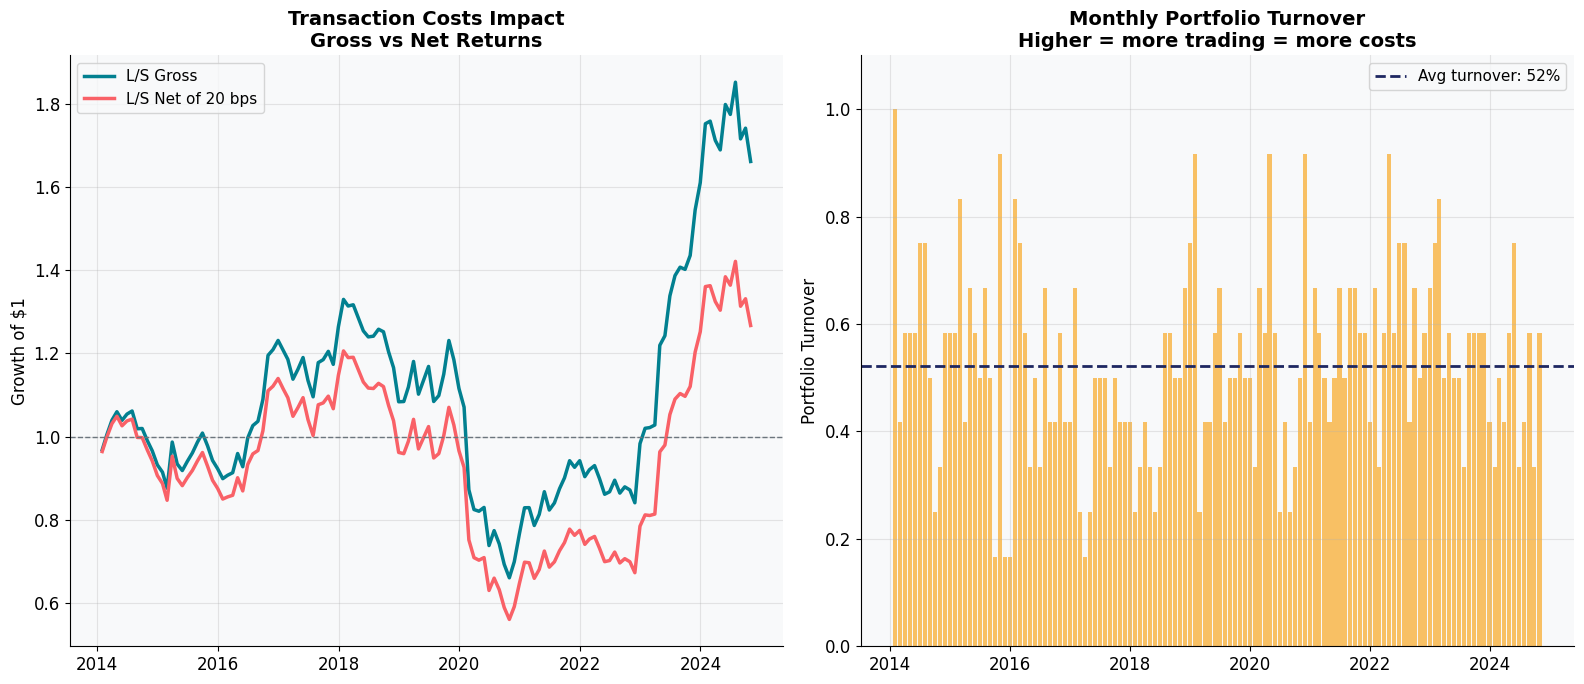


Performance After Costs:
  Gross annual return:     6.2%
  Net annual return:       3.7%
  Net Sharpe ratio:        0.21
  Avg monthly turnover:     52%
  Total cost drag:       27.17%

  Monthly rebalancing costs much less than daily trading (Week 5).


In [10]:
# ============================================================
# TRANSACTION COSTS AND TURNOVER
# ============================================================
np.random.seed(42)

def walk_forward_with_costs(data, features, model_class, model_kwargs,
                            min_train_months=36, cost_bps=20):
    dates_all = sorted(data['date'].unique())
    results = []
    prev_top = set()
    prev_bot = set()

    for i in range(min_train_months, len(dates_all) - 1):
        train_dates = dates_all[:i]
        test_date = dates_all[i]

        train = data[data['date'].isin(train_dates)]
        test = data[data['date'] == test_date].copy()

        if len(test) < 10:
            continue

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(train[features])
        y_tr = train['target'].values
        X_te = scaler.transform(test[features])

        model = model_class(**model_kwargs)
        model.fit(X_tr, y_tr)
        test['pred'] = model.predict(X_te)

        test = test.sort_values('pred', ascending=False)
        n = len(test)
        q_size = max(1, n // 5)

        top_set = set(test.head(q_size)['ticker'].values)
        bot_set = set(test.tail(q_size)['ticker'].values)

        # Turnover
        if prev_top:
            top_turn = len(top_set - prev_top) / q_size
            bot_turn = len(bot_set - prev_bot) / q_size
        else:
            top_turn = 1.0
            bot_turn = 1.0

        top_ret = test[test['ticker'].isin(top_set)]['target'].mean()
        bot_ret = test[test['ticker'].isin(bot_set)]['target'].mean()
        ls_gross = top_ret - bot_ret

        # Costs: turnover x cost per side x 2 sides
        avg_turn = (top_turn + bot_turn) / 2
        cost = cost_bps / 10000
        ls_net = ls_gross - avg_turn * cost * 2

        results.append({
            'date': test_date,
            'ls_gross': ls_gross,
            'ls_net': ls_net,
            'turnover': avg_turn,
            'cost': avg_turn * cost * 2,
        })

        prev_top = top_set
        prev_bot = bot_set

    return pd.DataFrame(results).set_index('date')

wf_costs = walk_forward_with_costs(
    data, features,
    RandomForestRegressor,
    {'n_estimators': 200, 'max_depth': 4, 'random_state': 42},
    cost_bps=20,
)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Gross vs Net cumulative
ax = axes[0]
ax.plot(wf_costs.index, (1 + wf_costs['ls_gross']).cumprod(),
        color=TEAL, linewidth=2.5, label='L/S Gross')
ax.plot(wf_costs.index, (1 + wf_costs['ls_net']).cumprod(),
        color=CORAL, linewidth=2.5, label='L/S Net of 20 bps')
ax.axhline(y=1, color=GRAY, linewidth=1, linestyle='--')
ax.set_ylabel('Growth of $1')
ax.set_title('Transaction Costs Impact\nGross vs Net Returns', fontweight='bold')
ax.legend(fontsize=11)

# Right: Monthly turnover
ax = axes[1]
ax.bar(wf_costs.index, wf_costs['turnover'], color=GOLD, alpha=0.7, width=25)
ax.axhline(y=wf_costs['turnover'].mean(), color=NAVY, linewidth=2,
           linestyle='--', label=f'Avg turnover: {wf_costs["turnover"].mean():.0%}')
ax.set_ylabel('Portfolio Turnover')
ax.set_title('Monthly Portfolio Turnover\nHigher = more trading = more costs',
             fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# Summary
gross_ann = wf_costs['ls_gross'].mean() * 12
net_ann = wf_costs['ls_net'].mean() * 12
net_vol = wf_costs['ls_net'].std() * np.sqrt(12)
net_sharpe = net_ann / net_vol if net_vol > 0 else 0
total_drag = wf_costs['cost'].sum()

print(f'\nPerformance After Costs:')
print(f'  Gross annual return:  {gross_ann:>7.1%}')
print(f'  Net annual return:    {net_ann:>7.1%}')
print(f'  Net Sharpe ratio:     {net_sharpe:>7.2f}')
print(f'  Avg monthly turnover: {wf_costs["turnover"].mean():>7.0%}')
print(f'  Total cost drag:      {total_drag:>7.2%}')
print(f'\n  Monthly rebalancing costs much less than daily trading (Week 5).')

### Checkpoint 3: The Cost of Trading

1. **How much did transaction costs reduce returns?** Compare gross to net. Is the strategy still worth the complexity after costs?

2. **Look at the turnover chart.** What fraction of the portfolio changes each month? Could you reduce costs by trading less frequently (e.g., quarterly rebalancing)?

3. **Compare costs here to Week 5.** In Week 5, daily trading at 5 bps destroyed most of the alpha. Is the impact here better or worse? Why? (Hint: trading frequency matters more than cost per trade.)

*Write your answers:*

### Checkpoint 3 Responses

1. Transaction costs reduce performance materially but do not fully eliminate it. Gross annual return is about 6.2%, net annual return is about 3.7%, and net Sharpe is about 0.21 (down from about 0.36 gross). Total cumulative cost drag is about 27.17% over the backtest.

2. Average monthly turnover is high at about 52%. That implies meaningful trading friction; less frequent rebalancing (for example quarterly) or rank-threshold trading would likely reduce costs.

3. Cost impact is better than Week 5 even though per-trade cost here is higher (20 bps vs 5 bps). The key reason is lower trading frequency: monthly rebalancing is far less destructive than daily turnover.

---

## Part 6: What Drives the Signal? (~5 min)

Which features matter most for ranking stocks? Understanding feature importance tells us whether the model is learning something sensible or just fitting noise.

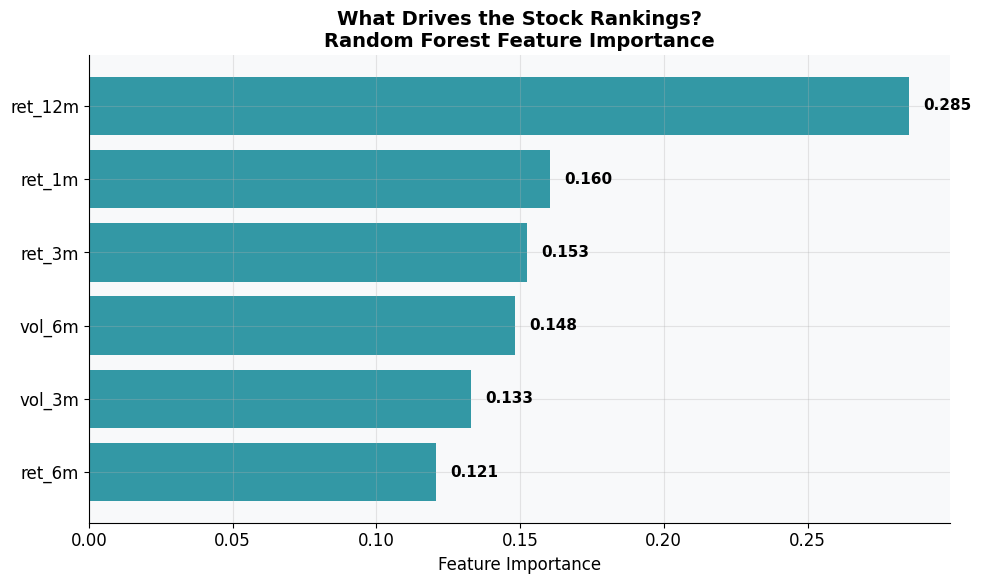

Feature Importances (descending):
  ret_12m       0.285
  ret_1m        0.160
  ret_3m        0.153
  vol_6m        0.148
  vol_3m        0.133
  ret_6m        0.121

Interpretation:
  Momentum features (past returns) typically dominate.
  This aligns with decades of research (Jegadeesh & Titman, 1993).
  Volatility captures risk: lower-vol stocks often outperform (low-vol anomaly).


In [12]:
# ============================================================
# FEATURE IMPORTANCE: What drives the ranking?
# ============================================================
train_fi = data[data['date'].isin(dates[:len(dates)-12])]
X_fi = StandardScaler().fit_transform(train_fi[features])
y_fi = train_fi['target'].values

rf_fi = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
rf_fi.fit(X_fi, y_fi)

fig, ax = plt.subplots(figsize=(10, 6))
importance = rf_fi.feature_importances_
sorted_idx = np.argsort(importance)
ax.barh(range(len(features)), importance[sorted_idx], color=TEAL, alpha=0.8)
ax.set_yticks(range(len(features)))
ax.set_yticklabels([features[i] for i in sorted_idx], fontsize=12)
ax.set_xlabel('Feature Importance')
ax.set_title('What Drives the Stock Rankings?\nRandom Forest Feature Importance',
             fontweight='bold')

# Annotate values
for i, (idx, imp) in enumerate(zip(sorted_idx, importance[sorted_idx])):
    ax.text(imp + 0.005, i, f'{imp:.3f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('Feature Importances (descending):')
for i in sorted_idx[::-1]:
    print(f'  {features[i]:12s}  {importance[i]:.3f}')

print('\nInterpretation:')
print('  Momentum features (past returns) typically dominate.')
print('  This aligns with decades of research (Jegadeesh & Titman, 1993).')
print('  Volatility captures risk: lower-vol stocks often outperform (low-vol anomaly).')

### Checkpoint 4: The Skeptic's Question

A colleague says: *"Your strategy just buys momentum — past winners keep winning. That's not ML, that's just the Jegadeesh-Titman (1993) momentum factor."*

**How would you respond?** Consider:
- Is momentum the dominant signal? Look at the feature importances.
- Does the ML model add anything beyond a simple "buy last year's winners" rule?
- What's the advantage of using ML here versus a simple sort on 12-month return?

*Write your answers:*

### Checkpoint 4 Responses

Momentum is the dominant feature, but not the only one.

ret_12m has the largest importance (about 0.285), while ret_1m (about 0.160), ret_3m (about 0.153), vol_6m (about 0.148), vol_3m (about 0.133), and ret_6m (about 0.121) all contribute.

So yes, momentum is central, but the model is not just a single-factor sort. Random Forest combines multiple horizons and volatility information nonlinearly, which can capture interactions a simple rule misses.

Evidence that ML adds some value in this run: Random Forest is best out-of-sample in the horse race (test IC about 0.076). It is only slightly above linear regression (about 0.070), but far better out-of-sample than overfit alternatives in this run.

Bottom line: ML helps as an ensemble ranking engine, but the edge is incremental and still must survive turnover, costs, and regime shifts.

---

## Part 7: Your Conclusion + Optional Extensions (~10 min)

### Core Deliverable: Written Conclusion

Answer the lab's central question:

> **Can ML rank which stocks will outperform next month — and is the resulting portfolio worth trading?**

Write 3–5 sentences. Reference specific numbers from your results (IC, Sharpe, turnover, cost impact). Compare this to Week 5's SPY direction prediction. What did you learn about how quantitative equity strategies actually work?

### Part 7 Conclusion

Yes, this lab shows ML can rank next-month stock performance with meaningful but modest signal: the best model (Random Forest) achieved test IC of about 0.076, and the walk-forward long/short portfolio produced about 6.2% gross annual return with a gross Sharpe near 0.36.
After transaction costs, performance dropped to about 3.7% annual return and Sharpe about 0.21, with average monthly turnover around 52% and cumulative cost drag around 27.17%, so implementation frictions are a major constraint.
Compared with Week 5 SPY direction prediction, this cross-sectional framework is more realistic because it focuses on relative ranking, portfolio construction, walk-forward validation, and cost-aware evaluation rather than a single binary forecast.
The key lesson is that small ranking edges can be useful, but real viability depends less on model complexity and more on robustness across regimes, turnover control, and honest post-cost testing.

### Optional Extensions (if time permits)

**Extension 1: Model Comparison** — Run the walk-forward with different models. Does model choice matter?
```python
wf_linear = walk_forward_ranking(data, features, LinearRegression, {})
wf_gb = walk_forward_ranking(data, features, GradientBoostingRegressor,
                              {'n_estimators': 200, 'max_depth': 3, 'random_state': 42})
```

**Extension 2: Larger Universe** — Add 20+ more tickers to the universe. Does more breadth improve the strategy or just add noise?

**Extension 3: Excess Returns** — Change the target to excess return over SPY: `data['excess_target'] = data['target'] - data['spy_next']`. Does predicting relative-to-market improve rankings?

**Extension 4: Decile Analysis** — Form 5 quintile portfolios instead of just top/bottom. Plot average return by quintile. Is the relationship monotonic (Q1 best, Q5 worst)?

**Extension 5: Turnover Control** — Only trade when a stock's rank changes by more than 1 quintile. How much does this reduce turnover and costs?

In [15]:
# YOUR EXTENSION EXPERIMENTS (optional)


---

## Key Takeaways

1. **Cross-sectional ranking is more realistic than index direction** — real quant strategies rank stocks against each other, not predict whether "the market" goes up
2. **Information Coefficient (IC) is the right metric** — Spearman rank correlation between predictions and outcomes, not classification accuracy
3. **Small ICs can be profitable** — an IC of 0.05 across 30 stocks each month creates real portfolio value when compounded
4. **Transaction costs still matter, but less** — monthly rebalancing costs far less than daily trading
5. **Momentum is the strongest simple signal** — but ML can combine multiple features non-linearly
6. **The real skill is evaluation, not modeling** — walk-forward splits, honest costs, and skepticism about overfitting matter more than model architecture

**The gap between Week 5 and today is the gap between a toy problem and a real one.**

---

*Next week: Text and news features — can LLMs extract better signals than price data alone?*